In [4]:
from __future__ import annotations

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pathlib import Path


# -----------------------------
# Coordinate systems
# -----------------------------

CRS_GEOGRAPHIC = "EPSG:4326"


# -----------------------------
# Map settings
# -----------------------------

OREGON_EXTENT = [
    -125,   # west
    -116,   # east
    42,     # south
    46.5    # north
]

MAP_PROJECTION = ccrs.PlateCarree()

tasmax_hist_dir = '/home/redmond/data/pub/scripps_downscaled_CMIP6/LOCA2/CONUS_regions_split/ACCESS-CM2/n_west/0p0625deg/r1i1p1f1/historical/tasmax/'
tasmin_hist_dir = '/home/redmond/data/pub/scripps_downscaled_CMIP6/LOCA2/CONUS_regions_split/ACCESS-CM2/n_west/0p0625deg/r1i1p1f1/historical/tasmin/'
tasmax_fut_dir = '/home/redmond/data/pub/scripps_downscaled_CMIP6/LOCA2/CONUS_regions_split/ACCESS-CM2/n_west/0p0625deg/r1i1p1f1/ssp585/tasmax/'
tasmin_fut_dir = '/home/redmond/data/pub/scripps_downscaled_CMIP6/LOCA2/CONUS_regions_split/ACCESS-CM2/n_west/0p0625deg/r1i1p1f1/ssp585/tasmin/'

tasmax_hist_file_path = tasmax_hist_dir + 'tasmax.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20220413.n_west.nc'
tasmin_hist_file_path = tasmin_hist_dir + 'tasmin.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20220413.n_west.nc'
tasmax_fut_file_path = tasmax_fut_dir + 'tasmax.ACCESS-CM2.ssp585.r1i1p1f1.2075-2100.LOCA_16thdeg_v20220413.n_west.nc'
tasmin_fut_file_path = tasmin_fut_dir + 'tasmin.ACCESS-CM2.ssp585.r1i1p1f1.2075-2100.LOCA_16thdeg_v20220413.n_west.nc'

CDD_baseline_c = 18 # ~65 F in C

In [2]:
tasmax_hist_da = xr.open_dataarray(tasmax_hist_file_path) - 273.15
tasmin_hist_da = xr.open_dataarray(tasmin_hist_file_path) - 273.15
tasmean_hist_da = (tasmax_hist_da + tasmin_hist_da) / 2
CDD_hist_da = (tasmean_hist_da - CDD_baseline_c)


In [5]:
tasmax_fut_da = xr.open_dataarray(tasmax_fut_file_path) - 273.15
tasmin_fut_da = xr.open_dataarray(tasmin_fut_file_path) - 273.15
tasmean_fut_da = (tasmax_fut_da + tasmin_fut_da) / 2
CDD_fut_da = (tasmean_fut_da - CDD_baseline_c)


Text(0.5, 1.0, 'Historical CDD (July)\n[1950-2014]')

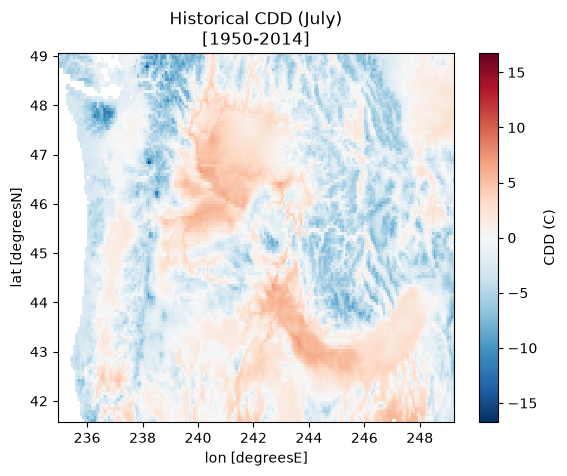

In [17]:
CDD_hist_da.sel(time=CDD_hist_da.time.dt.month.isin([7])).mean(dim='time').plot(cmap='RdBu_r', cbar_kwargs={'label': 'CDD (C)'})

plt.title('Historical CDD (July)\n[1950-2014]')

Text(0.5, 1.0, 'Future CDD (July)\n[2075-2100; ssp585]')

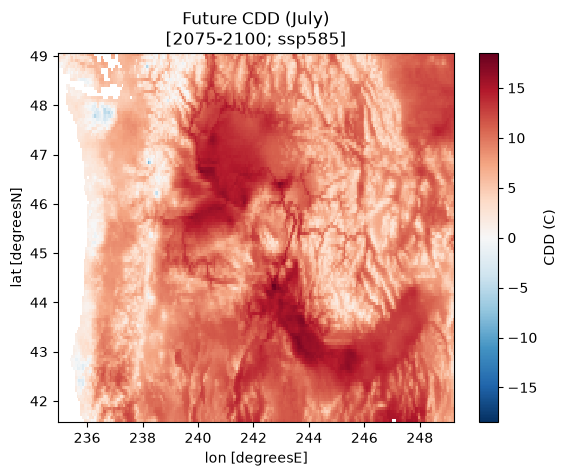

In [16]:
CDD_fut_da.sel(time=CDD_fut_da.time.dt.month.isin([7])).mean(dim='time').plot(cmap='RdBu_r', cbar_kwargs={'label': 'CDD (C)'})

plt.title('Future CDD (July)\n[2075-2100; ssp585]')


In [9]:
july_change = CDD_fut_da.sel(time=CDD_fut_da.time.dt.month.isin([7])).mean(dim='time') - CDD_hist_da.sel(time=CDD_hist_da.time.dt.month.isin([7])).mean(dim='time')

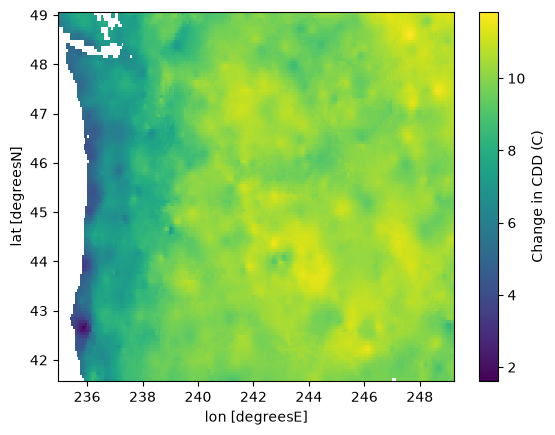

In [12]:
july_change.plot(cbar_kwargs={'label': 'Change in CDD (C)'})